In [20]:
#This notebook aims to develop a csv file that models BP cuff deflation for someone with hypertension


#Imports
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import csv
import statistics

#Importing healthy blood pressure data
b = pd.read_csv("Stage_1_Hyertension_JVT_12_2025.csv")
#Saving csv columns as data lists
disease_data = b.to_dict(orient="list")
#Saving each column as a discrete list
time = disease_data["0"]
disease_bp = disease_data["80"]
#Healthy BP data called h(t)

In [21]:
#Create Gaussian Function g(t)
#Takes in inputs of time and outputs values
#A is a scaling constant
def gauss(t, mu, sigma, A):
    g = A * np.exp(-1 * ((t - mu)**2) / (2 * sigma**2))
    return g

In [22]:
#Exponential decay
y0 = 180
k = 0.085

def decay(t, y0, k):
    c = y0 * np.exp(-k*t)
    return c

In [23]:
#saving linear decay data, need deflation pressure > 0 

t_decay = np.linspace(0, 22, 1208)
p = decay(t_decay, y0, k)


In [24]:
#Extracting when local maxima (systolic pressure) occurs
test = find_peaks(disease_bp)
peaks_index = test[0].tolist()
#peaks_index is a list of indices that correspond to pressure values in healthy_bp
systole = []
t_maxima = []
for x in range(0, len(peaks_index)):
    systole.append(disease_bp[peaks_index[x]])
    t_maxima.append(time[peaks_index[x]])

In [25]:
#extracting when local minima occurs
invert = []
for x in range(0, len(disease_bp)):
    invert.append(-1 * disease_bp[x])
mins = find_peaks(invert)
vall_index = mins[0].tolist()
#vall_index is a list of indices that ciorrespond to local pressure minima in healthy_bp
diastole = []
t_minima = []
for x in range(0, len(vall_index)):
    diastole.append(disease_bp[vall_index[x]])
    t_minima.append(time[vall_index[x]])

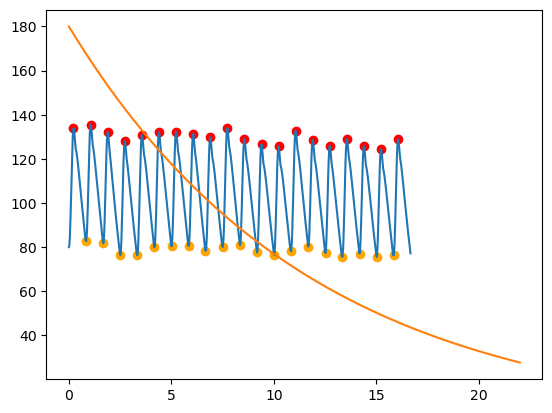

In [26]:
plt.scatter(t_maxima, systole, color="red")
plt.scatter(t_minima, diastole, color="orange")
plt.plot(time, disease_bp)
plt.plot(t_decay, p)

In [27]:

timestamps = []
index = []

for x in range(0, len(systole)):

    t = 0
    
    test = systole[x]

    for i in range(0, len(disease_bp)):

        if test == disease_bp[i]:
            
            timestamps.append(time[i])
            index.append(i)

diastolic_timestamps = []
d_index = []

for x in range(0, len(diastole)):

    t = 0

    test = diastole[x]

    for i in range(0, len(disease_bp)):

        if test == disease_bp[i]:

            diastolic_timestamps.append(time[i])
            d_index.append(i)

In [28]:
#Defining Gaussian Function and saving gaussian weights

#Calculating mean systole pressure
alpha = 0
for x in range(0, len(systole)):
    alpha = alpha + systole[x]
mean_systole = alpha / len(systole)

#Calculating mean diastole pressure
beta = 0
for x in range(0, len(diastole)):
    beta = beta + diastole[x]
mean_diastole = beta / len(diastole)

#Calculating standard deviation of mean systole pressure
sigma_systole = statistics.pvariance(systole, mu=mean_systole)
#Calculating standard deviation of mean diastole pressure
sigma_diastole = statistics.pvariance(diastole, mu=mean_diastole)

#Creating lists to save gaussian weights
systole_weights = []
diastole_weights = []

#Normalizing
sys_norm = 1/(sigma_systole * ((2*3.14)**0.5))
dias_norm = 1/(sigma_diastole * ((2*3.14)**0.5))

#Populating weights list
for x in range(0, len(systole)):
    entry = gauss(systole[x], mean_systole, sigma_systole, sys_norm)
    systole_weights.append(entry)
for x in range(0, len(diastole)):
    entry = gauss(diastole[x], mean_diastole, sigma_diastole, dias_norm)
    diastole_weights.append(entry)

In [29]:
m = []

for x in range(0, len(time)):
    g = 180 * np.exp(-0.085 * time[x])
    m.append(g)

#Adding systolic spikes
for x in range(0, len(index)):

    #Systolic spikes
    if x > 5 and x < 13:
        m[index[x]] = m[index[x]] + m[index[x]]*systole_weights[x]
    if x == 8:
        m[index[x]] = m[index[x]] + m[index[x]]*systole_weights[x]
    if x == 9:
        m[index[x]] = m[index[x]] + m[index[x]]*systole_weights[x]
    if x == 10:
        m[index[x]] = m[index[x]] + m[index[x]]*systole_weights[x]
    if x == 11:
        m[index[x]] = m[index[x]] + m[index[x]]*systole_weights[x]

#Adding diastolic spikes
for x in range(0, len(d_index)):

    #diastolic spikes, only going to add like 3 or 4 of them near the end
    if x > 12:
        m[d_index[x]] = m[d_index[x]] + m[d_index[x]]*diastole_weights[x]*0.15
    if x > 13:
        m[d_index[x]] = m[d_index[x]] + m[d_index[x]]*diastole_weights[x]*0.10

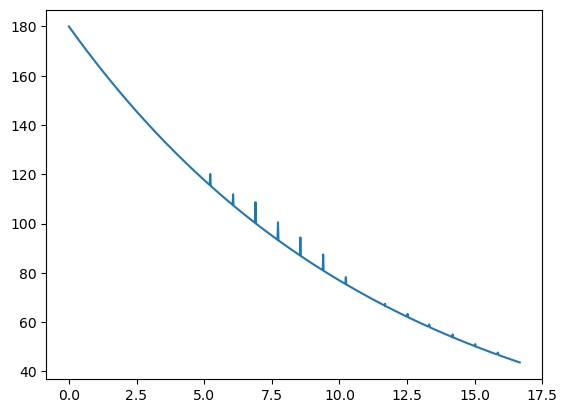

In [30]:
plt.plot(time, m)


In [31]:
#Exporting modulated dataset m as a csv file
with open("Hypertension_BP_CuffDecay_02182026.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(m)